In [ ]:
# Down stream application: PID tuning
import mujoco
import numpy as np
from scipy.stats import qmc
import math
import matplotlib.pyplot as plt
import mediapy as media
from tqdm import tqdm
import time, sys, datetime
from scipy.optimize import minimize, differential_evolution
import rootpath
root_dir = rootpath.detect()   # Get the root directory of the project (.git)
from pathlib import Path
sys.path.append(str(Path(root_dir)))
print(root_dir)
from utils.experiment import MujocoExperiment

# In some way, PID experiment is the specific child class of the MujocoExperiment
class Downstream_PID_experiment(object):
    def __init__(self):
        path = root_dir + "/models/SingleLeg_ideal.xml"
        self.experiment_instance = MujocoExperiment(path, model_type="ideal_geom_swing")
        
        # Model Parameter Set
        params = {
            'stiffness_MAA': 318.76,
            'stiffness_BAA': 315.8,
            'l10': 0.174,
            'l20': 0.2562,
            'damping_MAA': 11.34,
            'damping_BAA': 10.9,
            's1': 0.000654,
            's2': 0.000637,
            'c1_thigh': 0,
            'c2_calf': 0,
            'P1': 0,
            'P2': 0,
            'P1_prime': 0,
            'P2_prime': 0
        }
        self.experiment_instance.apply_params(params)

        # Run the Experiments
        self.framerate = 60

    def simulate_response_evaluate_pid(self, Kp, Ki, Kd, mode="optimize"):

        # exp_set
        duration_steady = 10  # seconds, the steady state time
        duration_experiment = 10  # seconds, the experiment time
        ifrender = True

        m, d = self.experiment_instance.model, self.experiment_instance.data

        # Reset state and time
        mujoco.mj_resetData(m, d)

        # Reset state and time
        results = []
        frames = []
        dt = m.opt.timestep

        # PID
        err_sum = [0.0, 0.0]
        last_err = [0.0, 0.0]
        error_list = []
        total_error = 0.0

        with mujoco.Renderer(m, self.experiment_instance.height, self.experiment_instance.width) as renderer:
            while d.time < duration_steady + duration_experiment:
                theta1 = d.qpos[0] + np.pi / 2
                theta2 = d.qpos[1] + 0
                u1 = 0
                u2 = 0
                l1, l2 = MujocoExperiment.calculate_length(theta1, theta2)
                l1_target, l2_target = MujocoExperiment.calculate_length(math.pi/2, 0)
                if d.time >= duration_steady:
                    err1 = l1_target - l1
                    err2 = l2_target - l2
                    err_sum[0] += err1 * dt
                    err_sum[1] += err2 * dt
                    derr1 = (err1 - last_err[0]) / dt
                    derr2 = (err2 - last_err[1]) / dt
                    u1 = Kp * err1 + Ki * err_sum[0] + Kd * derr1
                    u2 = Kp * err2 + Ki * err_sum[1] + Kd * derr2
                    # limit u1, u2 in [-100, 100]
                    u1 = np.clip(u1, -100, 100)
                    u2 = np.clip(u2, -100, 100)
                    last_err = [err1, err2]
                    d.ctrl[:2] = u1
                    d.ctrl[2:] = u2
                    total_error += err1**2 + err2**2
                    error_list.append(err1**2 + err2**2)
                else:
                    d.ctrl[:] = 0
                # update
                mujoco.mj_step(m, d)
                if mode == "validate":
                    if len(frames) < d.time * self.framerate:   # assume the simulation is running much faster than the rendering
                        if ifrender:
                            renderer.update_scene(d, camera="closeup")
                            frames.append(renderer.render())
                    results.append((d.time, theta1, theta2, u1, u2))
            if mode == "validate":
                time_sim, theta1_sim, theta2_sim, u1, u2 = np.array(results).T
                return np.mean(np.array(error_list)), time_sim, theta1_sim, theta2_sim, u1, u2, frames
            else:
                return np.mean(np.array(error_list))

mySim = Downstream_PID_experiment()

print("Begin optimization for PID parameters...")
exp_log = []

def pid_objective(x):
    Kp, Ki, Kd = x
    # Evaluate the PID parameters
    res = mySim.simulate_response_evaluate_pid(Kp, Ki, Kd)
    MSE = res
    return MSE

def record_best_x(xk, convergence=None):
    Kp, Ki, Kd = xk
    res = mySim.simulate_response_evaluate_pid(Kp, Ki, Kd, mode="validate")
    time, theta1, theta2, u1, u2, frames = res[1:]
    MSE = res[0]
    exp_log.append({
        'Kp': Kp,
        'Ki': Ki,
        'Kd': Kd,
        'MSE': MSE,
        'time': time,
        'theta1': theta1,
        'theta2': theta2,
        'u1': u1,
        'u2': u2,
        'frames': frames
    })
    print(f"Evaluating PID: Kp={Kp}, Ki={Ki}, Kd={Kd}, Total Error={MSE}")

# Step1: minimize the PID parameters using L-BFGS-B
x0 = [100.0, 0.0, 2.0]      # initialization
bounds = [(1, 10000), (0, 1000), (0, 100)]
res_local = minimize(pid_objective, x0, bounds=bounds, method='L-BFGS-B', callback=record_best_x, options={'disp': True, 'maxiter': 1000})

# Step2: use the result of L-BFGS-B as the prior sample for differential evolution
def make_init_population(bounds, prior_sample, popsize=10):
    dim = len(bounds)
    total_num = popsize * dim

    # 1. Latin Hypercube Sampling in [0,1]^dim
    sampler = qmc.LatinHypercube(d=dim)
    sample_unit = sampler.random(n=total_num - 1)  # -1 to leave space for prior

    # 2. Scale LHS to bounds
    lower_bounds = np.array([b[0] for b in bounds])
    upper_bounds = np.array([b[1] for b in bounds])
    sample_scaled = qmc.scale(sample_unit, lower_bounds, upper_bounds)

    # 3. Add prior sample (make sure it's within bounds)
    prior_sample_clipped = np.clip(prior_sample, lower_bounds, upper_bounds)
    init_population = np.vstack([sample_scaled, prior_sample_clipped])

    return init_population
init_population = make_init_population(bounds, res_local.x, popsize=10)
res = differential_evolution(pid_objective, init=init_population, bounds=bounds, popsize=10, disp=True, callback=record_best_x,  strategy='rand1bin', mutation=(0.05, 0.2))
print("Best PID:", res.x)

/Users/flypig/Documents/Coding/MujocoLearn
Begin optimization for PID parameters...
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         1 variables are exactly at the bounds

At iterate    0    f=  3.77287D-03    |proj g|=  8.50404D-05

At iterate    1    f=  3.77286D-03    |proj g|=  8.50401D-05
Evaluating PID: Kp=100.00001704202086, Ki=8.504035149681233e-05, Kd=1.9999996026182174, Total Error=0.003772863920483988

At iterate    2    f=  1.79446D-03    |proj g|=  2.91137D-05
Evaluating PID: Kp=113.89119050649485, Ki=35.96067798924386, Kd=8.347471253992712, Total Error=0.001794455556249145

At iterate    3    f=  1.33674D-03    |proj g|=  1.81760D-05
Evaluating PID: Kp=120.78165597398727, Ki=54.5268337439597, Kd=11.0241323393669, Total Error=0.0013367358104012122

At iterate    4    f=  9.03199D-04    |proj g|=  9.28438D-06
Evaluating PID: Kp=132.86656278189972, Ki=85.31278628358935, Kd=14.32491078506748, Tota

In [ ]:
# post-process the results: transform the results into csv format / np format
import pandas as pd

# save all PID as a csv file
kp = [expdata['Kp'] for expdata in exp_log]
ki = [expdata['Ki'] for expdata in exp_log]
kd = [expdata['Kd'] for expdata in exp_log]
mse = [expdata['MSE'] for expdata in exp_log]

df = pd.DataFrame({
    'Kp': kp,
    'Ki': ki,
    'Kd': kd,
    'MSE': mse
})
df.to_csv(root_dir + "/src/application/PID/data/parameters.csv", index=False)

# save time, theta1, theta2, u1, u2, frames as an ndarray
# squeeze
data_array = np.stack([
    np.stack([d['time'], d['theta1'], d['theta2'], d['u1'], d['u2']], axis=0)   # index: channel * time, eg, 5*100
    for d in exp_log
], axis=0)  # index: experiment * channel * time
np.save(root_dir + "/src/application/PID/data/experiment_data.npy", data_array)

# save the video
dt_str = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
for iteration in tqdm(range(len(exp_log)), desc="Saving video frames"):
    frames = exp_log[iteration]['frames']
    if len(frames) == 0:
        continue
    # save the video
    video_filename = root_dir + f"/src/application/PID/video/PID_{iteration}_{dt_str}.mp4"
    media.write_video(video_filename, frames, fps=mySim.framerate)

In [68]:
len(exp_log[0]['frames']), len(exp_log)

(1201, 15)

In [130]:
# load the parameter and experiment data, re-build the exp_log
exp_log_loaded = []
data_array = np.load(root_dir + "/src/application/PID/data/experiment_data.npy")
parameters_df = pd.read_csv(root_dir + "/src/application/PID/data/parameters.csv")
for idx in range(len(parameters_df)):
    Kp, Ki, Kd, MSE = parameters_df.iloc[idx]
    time_sim = data_array[idx, 0, :]
    theta1_sim = data_array[idx, 1, :]
    theta2_sim = data_array[idx, 2, :]
    u1_sim = data_array[idx, 3, :]
    u2_sim = data_array[idx, 4, :]
    frames_sim = []  # Placeholder for frames
    exp_log_loaded.append({
        'Kp': Kp,
        'Ki': Ki,
        'Kd': Kd,
        'MSE': MSE,
        'time': time_sim,
        'theta1': theta1_sim,
        'theta2': theta2_sim,
        'u1': u1_sim,
        'u2': u2_sim,
        'frames': frames_sim
    })

/var/folders/j1/jvx4zg8j2kd3f52pd5cjwjrw0000gn/T/ipykernel_57964/3947489064.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = cm.get_cmap('ocean')  # 可以换成 cividis, viridis, etc.


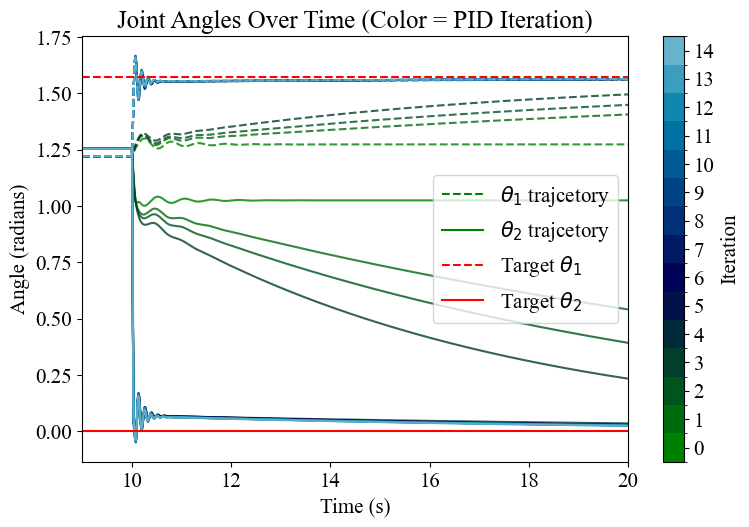

In [131]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.lines import Line2D
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams.update({
    'font.size': 15,  # 用作“字体大小 = 2”
    'axes.titlesize': 18,  # 用作“字体大小 = 1”
    'axes.labelsize': 15,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
    'figure.titlesize': 20,
})

def plot_pid_iterations_by_color(exp_log, duration_steady, duration_experiment):
    N = len(exp_log)
    # 生成截断并离散化的 colormap
    base_cmap = cm.get_cmap('ocean')  # 可以换成 cividis, viridis, etc.
    colors = base_cmap(np.linspace(0, 0.8, N))  # 截断前40%
    truncated_cmap = mcolors.ListedColormap(colors)

    # bounds = np.arange(N + 1)  # N 个颜色块需要 N+1 个边界
    # norm = mcolors.Normalize(vmin=-0.5, vmax=N-0.5)

    # 用 BoundaryNorm 精准控制颜色块位置
    boundaries = np.arange(N + 1) - 0.5  # [-0.5, 0.5, ..., N-0.5]
    norm = mcolors.BoundaryNorm(boundaries, N)
    
    sm = cm.ScalarMappable(cmap=truncated_cmap, norm=norm)
    sm.set_array([])

    plt.figure(figsize=(8, 10))

    # Subplot 1: Theta
    plt.subplot(2, 1, 1)
    for idx in range(len(exp_log)):
        Kp, Ki, Kd, MSE = exp_log[idx]['Kp'], exp_log[idx]['Ki'], exp_log[idx]['Kd'], exp_log[idx]['MSE']
        time_sim, theta1_sim, theta2_sim, u1_sim, u2_sim, frames_sim = exp_log[idx]['time'], exp_log[idx]['theta1'], exp_log[idx]['theta2'], exp_log[idx]['u1'], exp_log[idx]['u2'], exp_log[idx]['frames']
        color = truncated_cmap(idx)
        # time_sim, theta1_sim, theta2_sim, _, _, _ = mySim.simulate_response_evaluate_pid(Kp, Ki, Kd, mode="validate")
        plt.plot(time_sim, theta1_sim, linestyle='--', color=color, alpha=0.8, label=None)
        plt.plot(time_sim, theta2_sim, linestyle='-', color=color, alpha=0.8, label=None)
    # plt.colorbar(sm, label='Iteration', ax=plt.gca())
    cbar = plt.colorbar(sm, ax=plt.gca(), ticks=np.arange(N))
    cbar.set_label('Iteration')
    cbar.ax.set_yticklabels([str(i) for i in range(N)])  # 确保是整数标签
    plt.axhline(y=np.pi/2, color='r', linestyle='--', label='Target Theta1')
    plt.axhline(y=0, color='r', linestyle='-', label='Target Theta2')
    plt.xlim(duration_steady - 1, duration_steady + duration_experiment)
    plt.xlabel('Time (s)')
    plt.ylabel('Angle (radians)')
    plt.title('Joint Angles Over Time (Color = PID Iteration)')
    plt.legend(fontsize=8)
    
    custom_lines = [
        Line2D([0], [0], color='g', linestyle='--', label=r'$\theta_1$ trajcetory'),
        Line2D([0], [0], color='g', linestyle='-', label=r'$\theta_2$ trajcetory'),
        Line2D([0], [0], color='r', linestyle='--', label=r'Target $\theta_1$'),
        Line2D([0], [0], color='r', linestyle='-', label=r'Target $\theta_2$'),
    ]
    plt.legend(handles=custom_lines)

    # high resolution
    plt.tight_layout()
    plt.savefig(root_dir+"/src/application/PID/figure/joint_trajectory.png", dpi=300, bbox_inches='tight')  # PNG高清保存
    plt.show()

duration_steady = 10  # seconds, the steady state time
duration_experiment = 10  # seconds, the experiment time
plot_pid_iterations_by_color(exp_log_loaded, duration_steady, duration_experiment)